In [2]:
import sys
import os
# Add the project root to the Python path
project_root = '/Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn'
if project_root not in sys.path:
    sys.path.append(project_root)

import functools
import itertools
import operator
from typing import Any
import torch
from torch_geometric.data import Dataset, download_url
from torch.utils.data import random_split
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from bcos.modules import BcosLinear, BcosSequential
from sklearn.model_selection import train_test_split
from torch.nn import BCEWithLogitsLoss
from torch_geometric.datasets import BA2MotifDataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.nn.aggr import SumAggregation
from torch_geometric.utils import add_self_loops, degree
from torchmetrics import AUROC
from torchmetrics.classification import BinaryAccuracy
from tqdm import tqdm
import networkx as nx
import matplotlib.pyplot as plt
import torch.nn.functional as F
from bcosgnn.explain import explain


In [8]:
from torch_geometric.datasets import ZINC

root_path = '/Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/data/ZINC'

train_set = ZINC(root=root_path, subset = True, split = 'train')

val_set = ZINC(root=root_path, subset = True, split = 'val')

test_set = ZINC(root=root_path, subset = True, split = 'test')

train_loader = DataLoader(train_set , batch_size = 32, shuffle = True)

val_loader = DataLoader(val_set , batch_size = 32, shuffle = False)

test_loader = DataLoader(test_set , batch_size = 32, shuffle = False)

In [10]:
import torch.nn.functional as F
from torch.nn import Linear, Sequential, ReLU, BatchNorm1d, Embedding
from torch_geometric.nn import GINEConv, global_mean_pool

def get_stats(split_name):

    dataset = ZINC(root = root_path , subset = True, split = split_name)

    num_graphs = len(dataset)

    num_nodes = sum([d.num_nodes for d in dataset])/num_graphs

    num_edges = sum([d.num_edges for d in dataset])/num_graphs

    print(f'{split_name} set statistics:')
    print(f'Number of graphs: {num_graphs}')
    print(f'Average number of nodes per graph: {num_nodes}')
    print(f'Average number of edges per graph: {num_edges}')

    return dataset

train_dataset = get_stats('train')
val_dataset = get_stats('val')
test_dataset = get_stats('test')

train set statistics:
Number of graphs: 10000
Average number of nodes per graph: 23.1664
Average number of edges per graph: 49.8558
val set statistics:
Number of graphs: 1000
Average number of nodes per graph: 23.083
Average number of edges per graph: 49.692
test set statistics:
Number of graphs: 1000
Average number of nodes per graph: 23.117
Average number of edges per graph: 49.72


In [11]:
class SimpleGINE(torch.nn.Module):
    def __init__(self, hidden_dim=64):
        super(SimpleGINE, self).__init__()
        
        # 1. Input Embeddings (Atom types and Bond types)
        self.node_emb = Embedding(28, hidden_dim)
        self.edge_emb = Embedding(4, hidden_dim)

        # 2. GINE Layer 1
        self.mlp1 = Sequential(Linear(hidden_dim, hidden_dim), ReLU(), Linear(hidden_dim, hidden_dim))
        self.conv1 = GINEConv(self.mlp1)
        self.bn1 = BatchNorm1d(hidden_dim)

        # 3. GINE Layer 2
        self.mlp2 = Sequential(Linear(hidden_dim, hidden_dim), ReLU(), Linear(hidden_dim, hidden_dim))
        self.conv2 = GINEConv(self.mlp2)
        self.bn2 = BatchNorm1d(hidden_dim)

        # 4. GINE Layer 3
        self.mlp3 = Sequential(Linear(hidden_dim, hidden_dim), ReLU(), Linear(hidden_dim, hidden_dim))
        self.conv3 = GINEConv(self.mlp3)
        self.bn3 = BatchNorm1d(hidden_dim)

        # 5. Final Readout
        self.post_mp = Sequential(
            Linear(hidden_dim, hidden_dim // 2), 
            ReLU(), 
            Linear(hidden_dim // 2, 1)
        )

    def forward(self, x, edge_index, edge_attr, batch):
        # Convert raw integer features to embeddings
        x = self.node_emb(x.squeeze(-1))
        edge_attr = self.edge_emb(edge_attr)

        # Layer 1
        x = self.conv1(x, edge_index, edge_attr)
        x = self.bn1(x)
        x = F.relu(x)

        # Layer 2
        x = self.conv2(x, edge_index, edge_attr)
        x = self.bn2(x)
        x = F.relu(x)

        # Layer 3
        x = self.conv3(x, edge_index, edge_attr)
        x = self.bn3(x)
        x = F.relu(x)

        # Global Pooling (Graph-level representation)
        x = global_mean_pool(x, batch)

        # Regression Output
        return self.post_mp(x).view(-1)

Epoch 010 | Train MAE: 0.4241 | Val MAE: 0.5465
Epoch 020 | Train MAE: 0.4003 | Val MAE: 0.4207
Epoch 030 | Train MAE: 0.3744 | Val MAE: 0.5018
Epoch 040 | Train MAE: 0.3641 | Val MAE: 0.4069
Epoch 050 | Train MAE: 0.3465 | Val MAE: 0.7924
Epoch 060 | Train MAE: 0.3430 | Val MAE: 0.3650
Epoch 070 | Train MAE: 0.3080 | Val MAE: 0.3254
Epoch 080 | Train MAE: 0.2975 | Val MAE: 0.3368
Epoch 090 | Train MAE: 0.2872 | Val MAE: 0.3279
Epoch 100 | Train MAE: 0.2774 | Val MAE: 0.3228


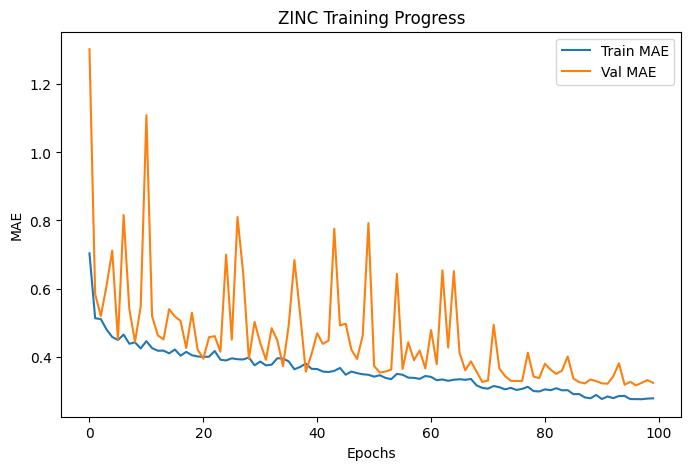


Final Test MAE: 0.3331


In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleGINE(hidden_dim=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader = DataLoader(val_set, batch_size=128)
test_loader = DataLoader(test_set, batch_size=128)

def train():
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        loss = F.l1_loss(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(train_set)

@torch.no_grad()
def test(loader):
    model.eval()
    total_mae = 0
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        total_mae += F.l1_loss(out, data.y).item() * data.num_graphs
    return total_mae / len(loader.dataset)

train_maes, val_maes = [], []
for epoch in range(1, 101):
    t_mae = train()
    v_mae = test(val_loader)
    train_maes.append(t_mae)
    val_maes.append(v_mae)
    scheduler.step(v_mae)
    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train MAE: {t_mae:.4f} | Val MAE: {v_mae:.4f}")

# Final Plotting
plt.figure(figsize=(8, 5))
plt.plot(train_maes, label='Train MAE')
plt.plot(val_maes, label='Val MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('ZINC Training Progress')
plt.legend()
plt.show()

# Final Inference
final_test_mae = test(test_loader)
print(f"\nFinal Test MAE: {final_test_mae:.4f}")

## BCos GINE (edge-aware) on ZINC
This section defines a BCos version of GINE (uses `edge_attr`) so the comparison with the vanilla `GINEConv` model above is faithful.

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing
from torch_geometric.nn.aggr import MeanAggregation


class Readout(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int | None = None, out_channels: int = 1, *, b: float = 2, max_out: int = 1):
        super().__init__()
        if hidden_channels is None:
            self.readout = BcosLinear(in_channels, out_channels, b=b, max_out=max_out)
        else:
            self.readout = nn.Sequential(
                BcosLinear(in_channels, hidden_channels, b=b, max_out=max_out),
                nn.ReLU(),
                BcosLinear(hidden_channels, out_channels, b=b, max_out=max_out),
            )

    def forward(self, x: torch.Tensor, batch: torch.Tensor) -> torch.Tensor:
        raise NotImplementedError


class ReadoutThenAgg(Readout):
    def __init__(self, in_channels: int, hidden_channels: int | None = None, out_channels: int = 1, *, b: float = 2, max_out: int = 1):
        super().__init__(in_channels, hidden_channels, out_channels, b=b, max_out=max_out)
        # Use mean aggregation to match `global_mean_pool` used in the vanilla GINE baseline.
        self.agg = MeanAggregation()

    def forward(self, x: torch.Tensor, batch: torch.Tensor) -> torch.Tensor:
        z = self.readout(x)
        out = self.agg(z, batch)
        return out


class BcosGINEConv(MessagePassing):
    def __init__(
        self,
        hidden_dim: int,
        *,
        b: float = 2,
        max_out: int = 1,
        eps: float = 0.0,
        train_eps: bool = False,
    ):
        super().__init__(aggr="add")
        self.nn = nn.Sequential(
            BcosLinear(hidden_dim, hidden_dim, b=b, max_out=max_out),
            nn.ReLU(),
            BcosLinear(hidden_dim, hidden_dim, b=b, max_out=max_out),
        )
        if train_eps:
            self.eps = nn.Parameter(torch.tensor([eps], dtype=torch.float))
        else:
            self.register_buffer("eps", torch.tensor([eps], dtype=torch.float))

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor) -> torch.Tensor:
        out = self.propagate(edge_index, x=x, edge_attr=edge_attr)
        out = (1 + self.eps) * x + out
        return self.nn(out)

    def message(self, x_j: torch.Tensor, edge_attr: torch.Tensor) -> torch.Tensor:
        # GINE-style message: ReLU(x_j + e_ij)
        return F.relu(x_j + edge_attr)

In [14]:
class BCosGINE(nn.Module):
    def __init__(self, hidden_dim: int = 128, *, b: float = 2, max_out: int = 1):
        super().__init__()
        # Match the vanilla baseline: same vocab sizes and embedding dim.
        self.node_emb = nn.Embedding(28, hidden_dim)
        self.edge_emb = nn.Embedding(4, hidden_dim)

        # Match the vanilla baseline: 3 GINE-style conv blocks + BN + ReLU.
        self.conv1 = BcosGINEConv(hidden_dim, b=b, max_out=max_out)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.conv2 = BcosGINEConv(hidden_dim, b=b, max_out=max_out)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.conv3 = BcosGINEConv(hidden_dim, b=b, max_out=max_out)
        self.bn3 = nn.BatchNorm1d(hidden_dim)

        # Use ReadoutThenAgg as requested (mean aggregation to align with `global_mean_pool`).
        self.readout = ReadoutThenAgg(hidden_dim, hidden_dim // 2, out_channels=1, b=b, max_out=max_out)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor, batch: torch.Tensor) -> torch.Tensor:
        x = self.node_emb(x.squeeze(-1).long())
        edge_attr = edge_attr.view(-1).long()
        edge_attr = self.edge_emb(edge_attr)

        x = self.conv1(x, edge_index, edge_attr)
        x = self.bn1(x)
        x = F.relu(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = self.bn2(x)
        x = F.relu(x)

        x = self.conv3(x, edge_index, edge_attr)
        x = self.bn3(x)
        x = F.relu(x)

        out = self.readout(x, batch)
        return out.view(-1)

In [16]:
# --- Quick sanity check (one batch) ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bcos_model = BCosGINE(hidden_dim=128, b=2, max_out=1).to(device)

batch_data = next(iter(train_loader)).to(device)
with torch.no_grad():
    out = bcos_model(batch_data.x, batch_data.edge_index, batch_data.edge_attr, batch_data.batch)
    loss = F.l1_loss(out, batch_data.y)
print('BCosGINE batch output shape:', tuple(out.shape))
print('BCosGINE batch MAE (L1):', float(loss))

BCosGINE batch output shape: (128,)
BCosGINE batch MAE (L1): 1.4490349292755127


## Train / Validate / Test: BCos GINE (ZINC)

In [ ]:
from copy import deepcopy


def _bcos_train_one_epoch(model: nn.Module, loader, optimizer: torch.optim.Optimizer, device: torch.device) -> float:
    model.train()
    total_mae = 0.0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad(set_to_none=True)
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        loss = F.l1_loss(out, data.y)
        loss.backward()
        optimizer.step()
        total_mae += loss.detach().item() * data.num_graphs
    return total_mae / len(loader.dataset)


@torch.no_grad()
def _bcos_eval_mae(model: nn.Module, loader, device: torch.device) -> float:
    model.eval()
    total_mae = 0.0
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        total_mae += F.l1_loss(out, data.y).item() * data.num_graphs
    return total_mae / len(loader.dataset)

/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_6502/685466501.py:14: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  total_mae += float(loss) * data.num_graphs


[BCosGINE] Epoch 001 | Train MAE: 0.8237 | Val MAE: 1.2404

[BCosGINE] Best Val MAE: 1.2404
[BCosGINE] Final Test MAE: 1.2920


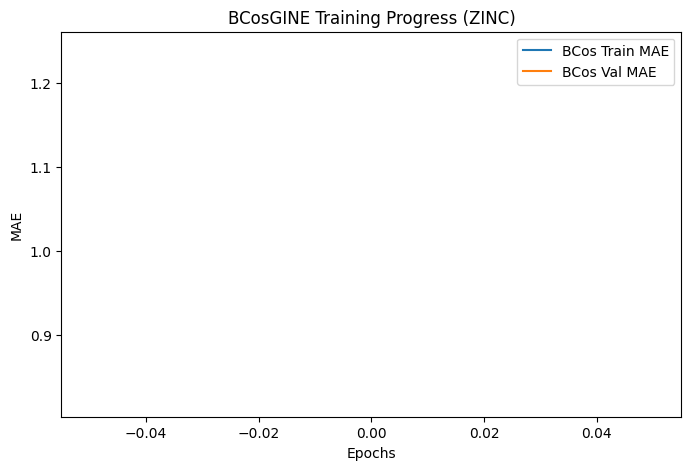

In [18]:
# Match the vanilla baseline hyperparams as closely as possible.
bcos_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bcos_model = BCosGINE(hidden_dim=128, b=2, max_out=1).to(bcos_device)

bcos_optimizer = torch.optim.Adam(bcos_model.parameters(), lr=0.001)
bcos_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    bcos_optimizer, mode='min', factor=0.5, patience=15
 )

num_epochs = 1  # set to 100 to match the vanilla run above
bcos_train_maes, bcos_val_maes = [], []
best_val = float('inf')
best_state = None

for epoch in range(1, num_epochs + 1):
    train_mae = _bcos_train_one_epoch(bcos_model, train_loader, bcos_optimizer, bcos_device)
    val_mae = _bcos_eval_mae(bcos_model, val_loader, bcos_device)
    bcos_train_maes.append(train_mae)
    bcos_val_maes.append(val_mae)
    bcos_scheduler.step(val_mae)

    if val_mae < best_val:
        best_val = val_mae
        best_state = deepcopy(bcos_model.state_dict())

    print(f"[BCosGINE] Epoch {epoch:03d} | Train MAE: {train_mae:.4f} | Val MAE: {val_mae:.4f}")

if best_state is not None:
    bcos_model.load_state_dict(best_state)

bcos_test_mae = _bcos_eval_mae(bcos_model, test_loader, bcos_device)
print(f"\n[BCosGINE] Best Val MAE: {best_val:.4f}")
print(f"[BCosGINE] Final Test MAE: {bcos_test_mae:.4f}")

# Plot curves (same style as vanilla)
plt.figure(figsize=(8, 5))
plt.plot(bcos_train_maes, label='BCos Train MAE')
plt.plot(bcos_val_maes, label='BCos Val MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('BCosGINE Training Progress (ZINC)')
plt.legend()
plt.show()